# 01 — Data Inspection & Subset Construction

This notebook:
1. Loads the HAM10000 metadata and inspects class distribution.
2. Defines a **binary** melanoma-vs-nevus mapping and drops all other classes.
3. Builds a **class-balanced** subset.
4. Resolves image paths and saves `data/processed/balanced_subset.csv`.
5. Displays representative samples for visual sanity-check.

In [1]:
import os
import sys
from pathlib import Path

# __file__ is not defined in Jupyter; search upward from cwd for skin_lesion/src/config.py
_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from config import SEED, RAW_DIR, PROCESSED_DIR, FIGURES_DIR

## 1 — Load metadata and inspect class distribution

HAM10000 contains **10 015 dermoscopy images** annotated with one of 7 diagnostic classes (`dx` column).  
Before any filtering we print the full distribution to understand the imbalance we will need to correct.

In [2]:
csv_path = RAW_DIR / "HAM10000_metadata.csv"
meta = pd.read_csv(csv_path)

print(f"Total rows: {len(meta)}")
print(f"Columns   : {list(meta.columns)}\n")

dist = meta["dx"].value_counts()
print("Full class distribution (dx):")
print(dist.to_string())
print(f"\nClass fractions:\n{(dist / dist.sum()).round(3).to_string()}")

Total rows: 10015
Columns   : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']

Full class distribution (dx):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115

Class fractions:
dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.011


## 2 — Binary mapping: melanoma vs. nevus

**Why only these two classes?**

The clinical task is *triage*: a patient either needs urgent referral (melanoma, `mel`) or can be safely monitored (benign).  
Melanocytic nevi (`nv`) are the most common benign differential diagnosis for melanoma and the two classes together account for > 80 % of the dataset, giving sufficient data for both pipelines.

Mapping:
- `label = 1` → **melanoma** (`dx == "mel"`)  ← positive class (the dangerous one)
- `label = 0` → **nevus**    (`dx == "nv"`)   ← negative class

All other classes are dropped to keep the problem strictly binary.

In [3]:
binary = meta[meta["dx"].isin(["mel", "nv"])].copy()
binary["label"] = (binary["dx"] == "mel").astype(int)

print("After binary filtering:")
print(binary["dx"].value_counts().to_string())
print(f"\nTotal rows kept: {len(binary)}")

After binary filtering:
dx
nv     6705
mel    1113

Total rows kept: 7818


## 3 — Class-balanced subset

**Why balance?**

Even after filtering to two classes, nevus images outnumber melanoma images by roughly 6 : 1.  
Training or evaluating on an imbalanced set would:
- Bias classifiers toward the majority class.
- Make accuracy a misleading metric (a naive classifier that always predicts nevus would score ~85 %).
- Inflate AUC estimates if calibration is poor.

**Strategy**: keep *all* melanoma images (the minority class) and randomly sample an equal number of nevus images.  
This is the simplest under-sampling approach; it preserves every positive example and avoids synthetic data generation.

In [4]:
mel_df = binary[binary["label"] == 1]
nv_df  = binary[binary["label"] == 0]

n_mel = len(mel_df)
nv_sampled = nv_df.sample(n=n_mel, random_state=SEED)

balanced = pd.concat([mel_df, nv_sampled]).reset_index(drop=True)

print(f"Melanoma rows : {n_mel}")
print(f"Nevus rows    : {len(nv_sampled)}")
print(f"Total balanced: {len(balanced)}")

Melanoma rows : 1113
Nevus rows    : 1113
Total balanced: 2226


## 4 — Resolve image paths

HAM10000 may be distributed with images spread across multiple subfolders  
(`HAM10000_images_part_1/`, `HAM10000_images_part_2/`, `images/`, …).  
We scan `data/raw/` recursively and build an `image_id → absolute_path` index  
so the rest of the pipeline works regardless of the exact folder layout.

In [5]:
# Build index: image_id (stem, no extension) → absolute path
image_index = {p.stem: p for p in RAW_DIR.rglob("*.jpg")}
print(f"Total .jpg files found under data/raw/: {len(image_index)}")

def resolve_path(image_id):
    p = image_index.get(image_id)
    return str(p) if p is not None else None

balanced["image_path"] = balanced["image_id"].apply(resolve_path)

missing = balanced["image_path"].isna().sum()
print(f"Images not found: {missing} / {len(balanced)}")
if missing > 0:
    print("Missing image_ids:", balanced.loc[balanced["image_path"].isna(), "image_id"].tolist())

Total .jpg files found under data/raw/: 10015
Images not found: 0 / 2226


## 5 — Save balanced subset to CSV

In [6]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "balanced_subset.csv"
balanced.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

Saved to: /Users/thomasbove/Desktop/skin_lesion_project/skin_lesion/data/processed/balanced_subset.csv


## 6 — Visual sanity check: sample images

We display **4 melanoma** and **4 nevus** examples in a 2 × 4 grid.  
This confirms that image paths were resolved correctly and gives an intuition  
for the visual differences (irregular borders / colour variation in melanoma vs.  
uniform, symmetric appearance in nevus).

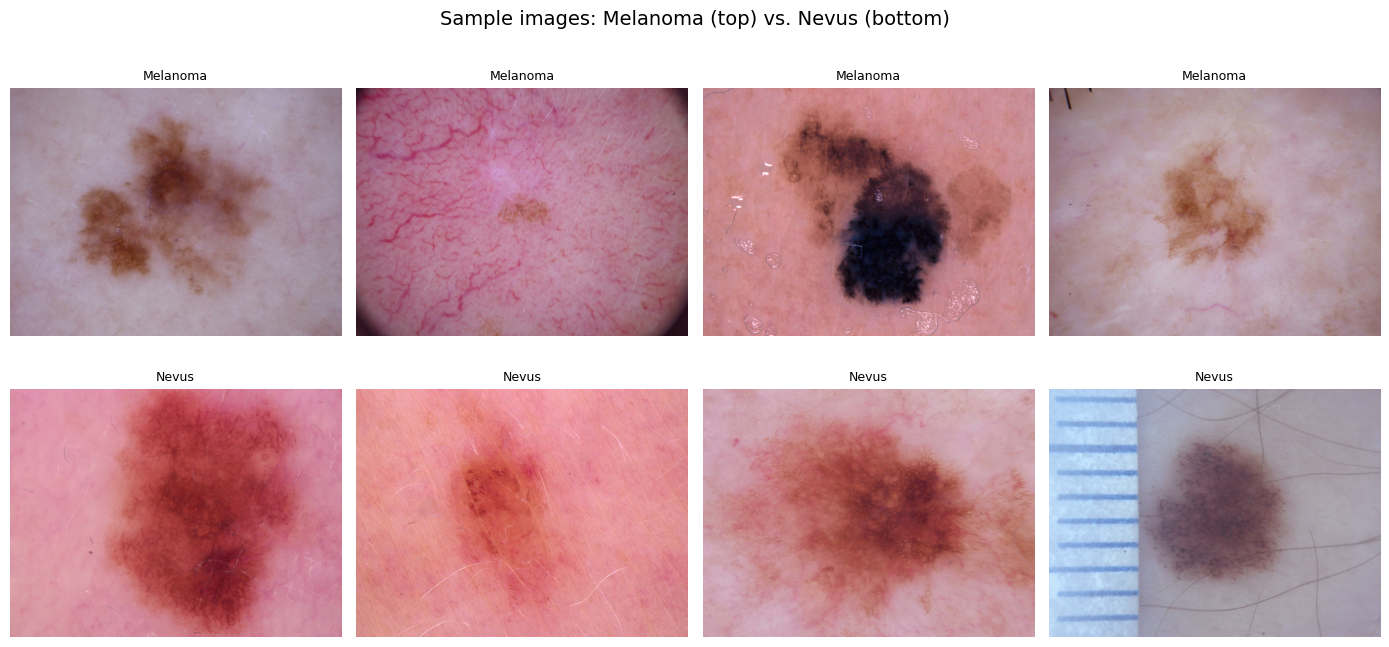

Figure saved to: /Users/thomasbove/Desktop/skin_lesion_project/skin_lesion/results/figures/sample_classes.png


In [7]:
rng = np.random.default_rng(SEED)

def sample_paths(df, label, n=4):
    subset = df[(df["label"] == label) & df["image_path"].notna()]
    idx = rng.choice(len(subset), size=min(n, len(subset)), replace=False)
    return subset.iloc[idx]["image_path"].tolist()

mel_paths = sample_paths(balanced, label=1, n=4)
nv_paths  = sample_paths(balanced, label=0, n=4)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample images: Melanoma (top) vs. Nevus (bottom)", fontsize=14)

for col, path in enumerate(mel_paths):
    axes[0, col].imshow(mpimg.imread(path))
    axes[0, col].set_title("Melanoma", fontsize=9)
    axes[0, col].axis("off")

for col, path in enumerate(nv_paths):
    axes[1, col].imshow(mpimg.imread(path))
    axes[1, col].set_title("Nevus", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "sample_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'sample_classes.png'}")

## 7 — Final summary

In [8]:
counts = balanced["label"].value_counts().sort_index()
print("Final class counts in balanced_subset.csv:")
print(f"  label=0 (nevus)    : {counts[0]}")
print(f"  label=1 (melanoma) : {counts[1]}")
print(f"  Total              : {len(balanced)}")
print(f"\nImages with resolved path: {balanced['image_path'].notna().sum()} / {len(balanced)}")

Final class counts in balanced_subset.csv:
  label=0 (nevus)    : 1113
  label=1 (melanoma) : 1113
  Total              : 2226

Images with resolved path: 2226 / 2226
